La intención del siguiente proyecto es para fines academicos, y tratara de investigar y conocer que factores inlfuyen oh aumentan en la probabilidad de presentar un paro cardiaco.
Se usara el data set de kaggle Heart attack Data Set, el cual se conforma por las siguientes columnas:
- 

In [21]:
import pandas as pd 
import matplotlib.pyplot as plt 

data = pd.read_csv('./data/raw/HeartAttackDataSet.csv')

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


#### Columnas:
- age = Edad
- sex = Sexo
- cp = Dolor de pecho (ChestPain)
- trestbps = Presion Sanguinea
- chol = Colesterol
- fbs = Glucosa en sangre
- restecg = Resultado de electrocardiograma, es decir si cuenta con dicho estudio.
- thalach = Frecuencia cardiaca maxima, solo se contemplo la maxima FC registrada.
- exang = Angina de pecho (Presenta dolor 1 si 0 no)
- oldpeak = depresion del segmento ST
- slope = Otro estudio de electrocardiograma
- ca = Grandes basos
- thal = Talasemia un transtorno sanguineo
- Target = Presento ataque cardiaco ( 1 si 0 no)


C:\Users\asjer\AppData\Local\Temp\ipykernel_8032\2680388538.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='target', y='percent', data=target_percent, palette='viridis')


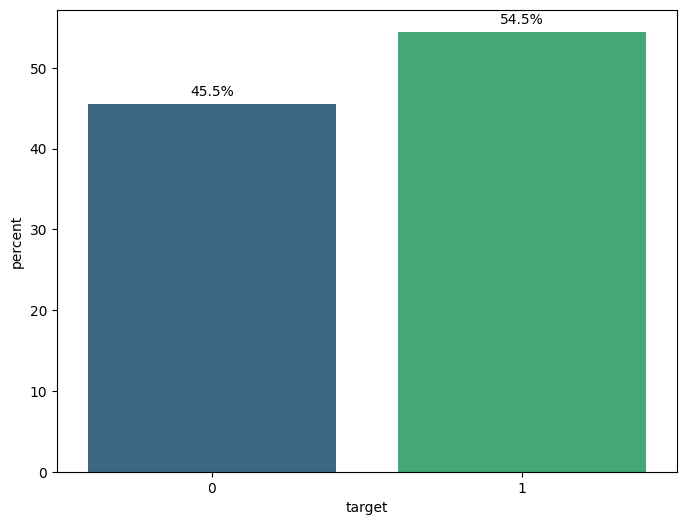

In [22]:
import seaborn as sns
target_percent = data['target'].value_counts(normalize=True).mul(100).rename('percent').reset_index()
target_percent.columns = ['target', 'percent']

plt.figure(figsize=(8,6))
ax = sns.barplot(x='target', y='percent', data=target_percent, palette='viridis')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.show()

Observamos un data set bastante balanceado, por lo cual lo ideal sera entrenar un modelo basado en arboles, como tree_decision oh xgboost que es el mas moderno e incluye optuna para su optimizacion de hiperparametros basado en algoritmos bayesianos.

In [23]:
# Busqueda de nulos
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

El data set no cuenta con valores nulos y todas sus variables son int64 lo cual es bueno ya que podriamos generar un mapa de calor directamente sin tratar las variables.

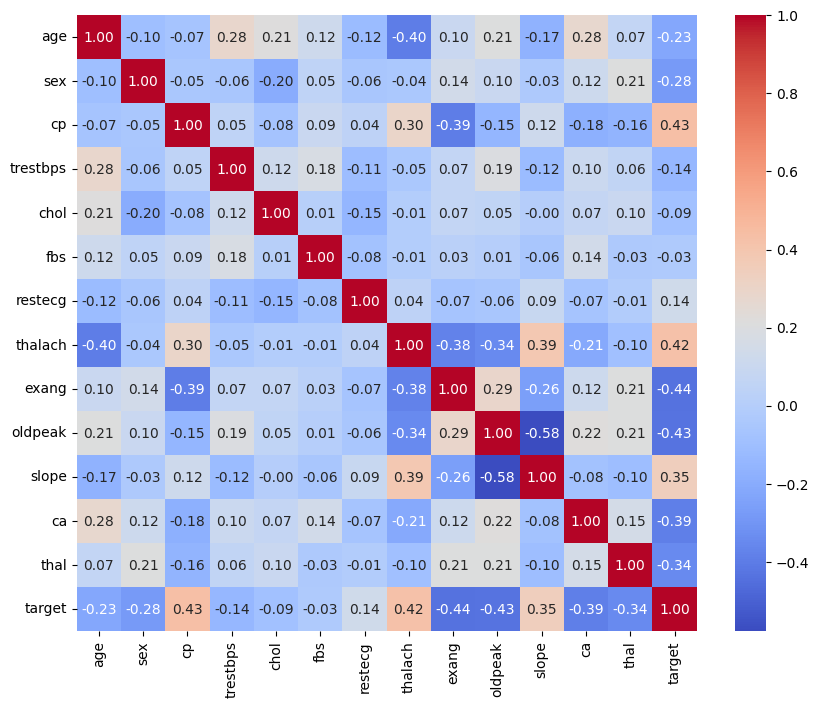

In [24]:
corr_matrix = data.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

### Ingenieria de caracteristicas
Dado que entrenaremos un modelo xgboost no es necesario escalar las features ya que 

In [27]:

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model= XGBClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred


array([0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1])

In [29]:
# Metricas para valorar el rendimiento

auc = roc_auc_score(y_test, y_pred)
print(f"AUC: {auc:.2f}")

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

AUC: 0.79
Accuracy: 0.80
